In [3]:
#pip install seaborn matplotlib transformers tokenizers sacrebleu datasets SentencePiece unbabel-comet

In [1]:
import math
import copy
import time
import random
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
#All we need is attention ...
def scaled_dot_product_attention(
    Q: torch.Tensor,              # (batch, heads, seq_q, d_k)
    K: torch.Tensor,              # (batch, heads, seq_k, d_k)
    V: torch.Tensor,              # (batch, heads, seq_k, d_v)
    mask: Optional[torch.Tensor] = None,  # (batch, 1, seq_q, seq_k)
    dropout: Optional[nn.Dropout] = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Vaswani et al. (2017) Equation (1):
        Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V

    Returns:
        output  : (batch, heads, seq_q, d_v)
        weights : (batch, heads, seq_q, seq_k)  — for visualization
    """
    d_k = Q.size(-1)

    # Step 1: Compute raw attention scores  (batch, heads, seq_q, seq_k)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # Step 2: Apply optional mask (causal or padding)
    # mask=True  →  keep,  mask=False  →  fill with -inf  →  softmax≈0
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # Step 3: Softmax over key dimension → attention weights
    attn_weights = F.softmax(scores, dim=-1)

    # Replace NaN from all-masked rows (happens at padded positions)
    attn_weights = torch.nan_to_num(attn_weights, nan=0.0)

    if dropout is not None:
        attn_weights = dropout(attn_weights)

    # Step 4: Weighted sum of values
    output = torch.matmul(attn_weights, V)
    return output, attn_weights


# ---------- Quick sanity check -------------------------------------------
B, H, S, d_k = 2, 4, 6, 16
Q_ = torch.randn(B, H, S, d_k)
K_ = torch.randn(B, H, S, d_k)
V_ = torch.randn(B, H, S, d_k)
out_, weights_ = scaled_dot_product_attention(Q_, K_, V_)
print(f'output shape   : {out_.shape}')      # (2, 4, 6, 16)
print(f'weights shape  : {weights_.shape}')  # (2, 4, 6, 6)
print(f'weights sum    : {weights_[0,0].sum(dim=-1)}')  # all 1.0


output shape   : torch.Size([2, 4, 6, 16])
weights shape  : torch.Size([2, 4, 6, 6])
weights sum    : tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [3]:
class MultiHeadAttention(nn.Module):
    """Vaswani et al. (2017) Equations (2–4)."""

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'

        self.d_model    = d_model
        self.num_heads  = num_heads
        self.d_k        = d_model // num_heads  # per-head dimension

        # Four projection matrices: Q, K, V projections + output projection
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        self.dropout = nn.Dropout(dropout)
        self.attn_weights = None  # stored for visualization

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(batch, seq, d_model) → (batch, heads, seq, d_k)"""
        B, S, _ = x.shape
        x = x.view(B, S, self.num_heads, self.d_k)
        return x.transpose(1, 2)  # (B, heads, S, d_k)

    def combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(batch, heads, seq, d_k) → (batch, seq, d_model)"""
        B, H, S, d_k = x.shape
        x = x.transpose(1, 2).contiguous()   # (B, S, H, d_k)
        return x.view(B, S, H * d_k)         # (B, S, d_model)

    def forward(
        self,
        query: torch.Tensor,        # (B, S_q, d_model)
        key:   torch.Tensor,        # (B, S_k, d_model)
        value: torch.Tensor,        # (B, S_k, d_model)
        mask:  Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        # Project and split into heads
        Q = self.split_heads(self.W_q(query))  # (B, H, S_q, d_k)
        K = self.split_heads(self.W_k(key))    # (B, H, S_k, d_k)
        V = self.split_heads(self.W_v(value))  # (B, H, S_k, d_k)

        # Scaled dot-product attention for all heads in parallel
        attn_output, self.attn_weights = scaled_dot_product_attention(
            Q, K, V, mask=mask, dropout=self.dropout
        )  # (B, H, S_q, d_k)

        # Concatenate heads and project
        combined = self.combine_heads(attn_output)  # (B, S_q, d_model)
        return self.W_o(combined)                   # (B, S_q, d_model)


In [4]:
class FeedForward(nn.Module):
    """Position-wise FFN. Vaswani et al. (2017) Equation (2)."""

    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)   # (B, S, d_model)


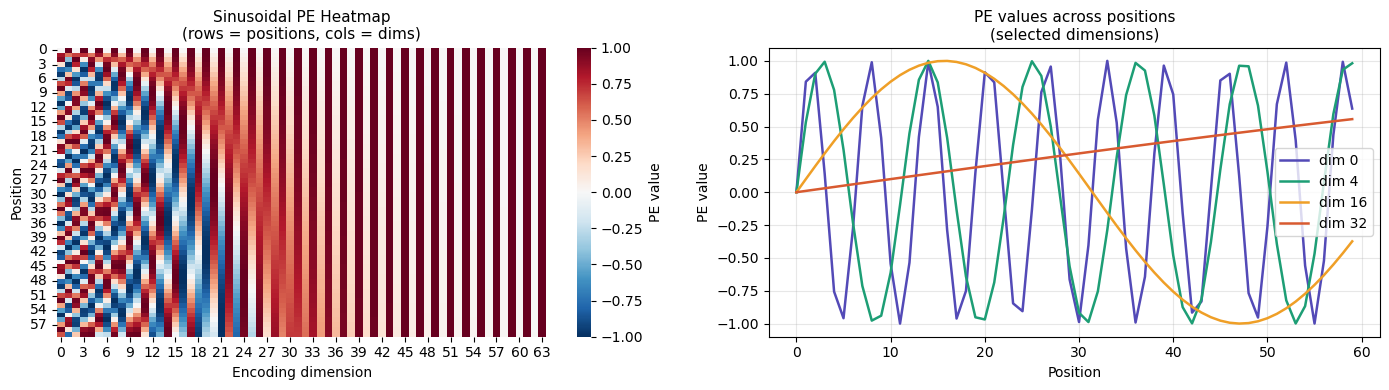

Lower dims oscillate FAST (local context).
Higher dims oscillate SLOW (global context).


In [5]:
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding. Vaswani et al. (2017) Equations (5–6)."""

    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Build the full encoding table once at construction time
        pe = torch.zeros(max_len, d_model)              # (max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1)   # (max_len, 1)

        # Exponent term: 10000^(2i/d_model)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)   # even dims
        pe[:, 1::2] = torch.cos(position * div_term)   # odd dims

        # Register as buffer (not a parameter — not trained)
        self.register_buffer('pe', pe.unsqueeze(0))     # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, S, d_model)  →  add PE for positions 0..S-1
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# ---------- Visualize positional encodings -----------------------------------
def plot_positional_encoding(d_model: int = 64, max_len: int = 60):
    pe_layer = PositionalEncoding(d_model, max_len, dropout=0.0)
    pe = pe_layer.pe[0].detach().numpy()   # (max_len, d_model)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Heatmap
    sns.heatmap(pe, ax=axes[0], cmap='RdBu_r', center=0,
                cbar_kws={'label': 'PE value'})
    axes[0].set_title('Sinusoidal PE Heatmap\n(rows = positions, cols = dims)',
                       fontsize=11)
    axes[0].set_xlabel('Encoding dimension')
    axes[0].set_ylabel('Position')

    # Individual dimension curves
    colors = ['#534AB7', '#1D9E75', '#EF9F27', '#D85A30']
    for idx, (dim, c) in enumerate(zip([0, 4, 16, 32], colors)):
        axes[1].plot(pe[:, dim], label=f'dim {dim}', color=c, linewidth=1.8)
    axes[1].set_title('PE values across positions\n(selected dimensions)', fontsize=11)
    axes[1].set_xlabel('Position')
    axes[1].set_ylabel('PE value')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    print('Lower dims oscillate FAST (local context).')
    print('Higher dims oscillate SLOW (global context).')


plot_positional_encoding()


In [6]:
class EncoderLayer(nn.Module):
    """
    Single encoder layer:
        x → Self-Attention → Add&Norm → FFN → Add&Norm

    We use Pre-LN (LayerNorm before sublayer) for training stability.
    """

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        src_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        # Pre-LN self-attention with residual
        x_norm = self.norm1(x)
        x = x + self.dropout(self.self_attn(x_norm, x_norm, x_norm, src_mask))

        # Pre-LN FFN with residual
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x


class DecoderLayer(nn.Module):
    """
    Single decoder layer:
        x → Masked Self-Attention → Add&Norm
          → Cross-Attention (over encoder output) → Add&Norm
          → FFN → Add&Norm
    """

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.self_attn   = MultiHeadAttention(d_model, num_heads, dropout)
        self.cross_attn  = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn         = FeedForward(d_model, d_ff, dropout)
        self.norm1       = nn.LayerNorm(d_model)
        self.norm2       = nn.LayerNorm(d_model)
        self.norm3       = nn.LayerNorm(d_model)
        self.dropout     = nn.Dropout(dropout)

    def forward(
        self,
        x:        torch.Tensor,           # decoder input
        enc_out:  torch.Tensor,           # encoder output (K, V for cross-attn)
        src_mask: Optional[torch.Tensor] = None,  # padding mask
        tgt_mask: Optional[torch.Tensor] = None,  # causal mask
    ) -> torch.Tensor:
        # Masked self-attention (cannot attend to future positions)
        x_norm = self.norm1(x)
        x = x + self.dropout(self.self_attn(x_norm, x_norm, x_norm, tgt_mask))

        # Cross-attention: decoder queries, encoder keys & values
        x_norm = self.norm2(x)
        x = x + self.dropout(self.cross_attn(x_norm, enc_out, enc_out, src_mask))

        # FFN
        x = x + self.dropout(self.ffn(self.norm3(x)))
        return x


In [7]:
class Encoder(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, num_heads: int,
                 d_ff: int, num_layers: int, dropout: float = 0.1,
                 max_len: int = 512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        # Scale embeddings by sqrt(d_model) (Vaswani et al. Section 3.4)
        self.scale = math.sqrt(d_model)

    def forward(self, src: torch.Tensor,
                src_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x = self.pos_enc(self.embedding(src) * self.scale)
        for layer in self.layers:
            x = layer(x, src_mask)
        return self.norm(x)


class Decoder(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, num_heads: int,
                 d_ff: int, num_layers: int, dropout: float = 0.1,
                 max_len: int = 512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.scale = math.sqrt(d_model)

    def forward(self, tgt: torch.Tensor, enc_out: torch.Tensor,
                src_mask: Optional[torch.Tensor] = None,
                tgt_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x = self.pos_enc(self.embedding(tgt) * self.scale)
        for layer in self.layers:
            x = layer(x, enc_out, src_mask, tgt_mask)
        return self.norm(x)


class Transformer(nn.Module):
    """Full encoder-decoder Transformer for sequence-to-sequence tasks."""

    def __init__(
        self,
        src_vocab_size: int,
        tgt_vocab_size: int,
        d_model:     int = 256,
        num_heads:   int = 8,
        d_ff:        int = 1024,
        num_layers:  int = 4,
        dropout:     float = 0.1,
        max_len:     int = 512,
    ):
        super().__init__()
        self.encoder    = Encoder(src_vocab_size, d_model, num_heads, d_ff, num_layers, dropout, max_len)
        self.decoder    = Decoder(tgt_vocab_size, d_model, num_heads, d_ff, num_layers, dropout, max_len)
        self.output_proj = nn.Linear(d_model, tgt_vocab_size)

        # Weight tying: share embedding weights with output projection
        # (Press & Wolf, 2017 — improves perplexity)
        if src_vocab_size == tgt_vocab_size:
            self.output_proj.weight = self.encoder.embedding.weight

        self._init_weights()

    def _init_weights(self):
        """Xavier uniform initialization for all linear/embedding layers."""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    @staticmethod
    def make_causal_mask(size: int, device: torch.device) -> torch.Tensor:
        """Upper-triangular mask: position i can only attend to j <= i."""
        # Returns (1, 1, size, size) bool tensor
        mask = torch.tril(torch.ones(size, size, device=device)).unsqueeze(0).unsqueeze(0)
        return mask.bool()

    @staticmethod
    def make_padding_mask(seq: torch.Tensor, pad_idx: int = 0) -> torch.Tensor:
        """(B, S) → (B, 1, 1, S) bool mask: True where token is NOT padding."""
        return (seq != pad_idx).unsqueeze(1).unsqueeze(2)

    def forward(
        self,
        src: torch.Tensor,   # (B, S_src) token ids
        tgt: torch.Tensor,   # (B, S_tgt) token ids (teacher-forced)
        src_pad_idx: int = 0,
        tgt_pad_idx: int = 0,
    ) -> torch.Tensor:       # (B, S_tgt, tgt_vocab_size) logits
        src_mask = self.make_padding_mask(src, src_pad_idx)  # (B,1,1,S_src)
        tgt_mask = self.make_causal_mask(tgt.size(1), tgt.device)  # (1,1,S,S)
        tgt_pad  = self.make_padding_mask(tgt, tgt_pad_idx)  # (B,1,1,S_tgt)
        tgt_mask = tgt_mask & tgt_pad  # combine causal + padding

        enc_out = self.encoder(src, src_mask)                # (B, S_src, d)
        dec_out = self.decoder(tgt, enc_out, src_mask, tgt_mask)  # (B, S_tgt, d)
        return self.output_proj(dec_out)                     # (B, S_tgt, V)


# ---------- Model summary ---------------------------------------------------
SRC_VOCAB = TGT_VOCAB = 10000
model = Transformer(SRC_VOCAB, TGT_VOCAB, d_model=256, num_heads=8,
                    d_ff=1024, num_layers=4).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')

# Dummy forward pass
src_dummy = torch.randint(1, SRC_VOCAB, (4, 20)).to(DEVICE)
tgt_dummy = torch.randint(1, TGT_VOCAB, (4, 18)).to(DEVICE)
logits = model(src_dummy, tgt_dummy)
print(f'Output logits shape : {logits.shape}')  # (4, 18, 10000)


Total parameters    : 12,491,536
Trainable parameters: 12,491,536
Output logits shape : torch.Size([4, 18, 10000])


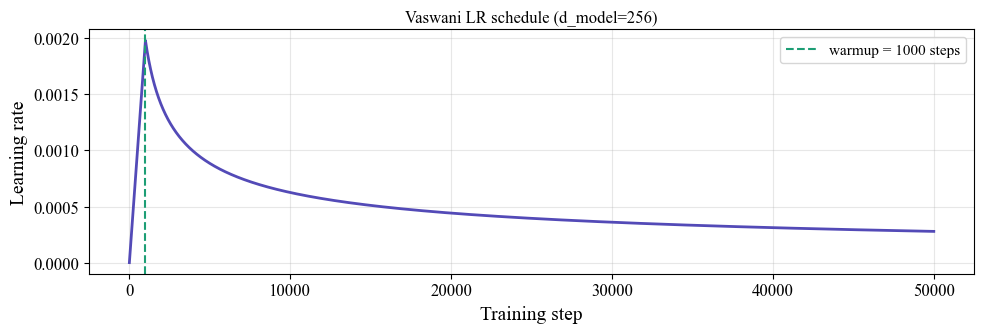

Peak LR at step 1000: 0.001976


In [93]:
class WarmupScheduler:
    """Vaswani et al. (2017) Equation (3)."""

    def __init__(self, optimizer, d_model: int, warmup_steps: int = 4000):
        self.optimizer     = optimizer
        self.d_model       = d_model
        self.warmup_steps  = warmup_steps
        self._step         = 0

    def step(self):
        self._step += 1
        lr = self._get_lr()
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

    def _get_lr(self) -> float:
        t = self._step
        return (self.d_model ** -0.5) * min(t ** -0.5, t * self.warmup_steps ** -1.5)


# Visualize the schedule
d_model, warmup = 256, 1000
steps = np.arange(1, 50001)
lrs = (d_model ** -0.5) * np.minimum(steps ** -0.5, steps * warmup ** -1.5)

plt.figure(figsize=(10, 3.5))
plt.plot(steps, lrs, color='#534AB7', linewidth=2)
plt.axvline(warmup, color='#1D9E75', linestyle='--', linewidth=1.5, label=f'warmup = {warmup} steps')
plt.xlabel('Training step'); plt.ylabel('Learning rate'); plt.grid(alpha=0.3)
plt.title(f'Vaswani LR schedule (d_model={d_model})', fontsize=12)
plt.legend(); plt.tight_layout(); plt.show()
print(f'Peak LR at step {warmup}: {lrs[warmup-1]:.6f}')


C:\Users\rrive\AppData\Local\Temp\ipykernel_45440\3623215953.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Purples')


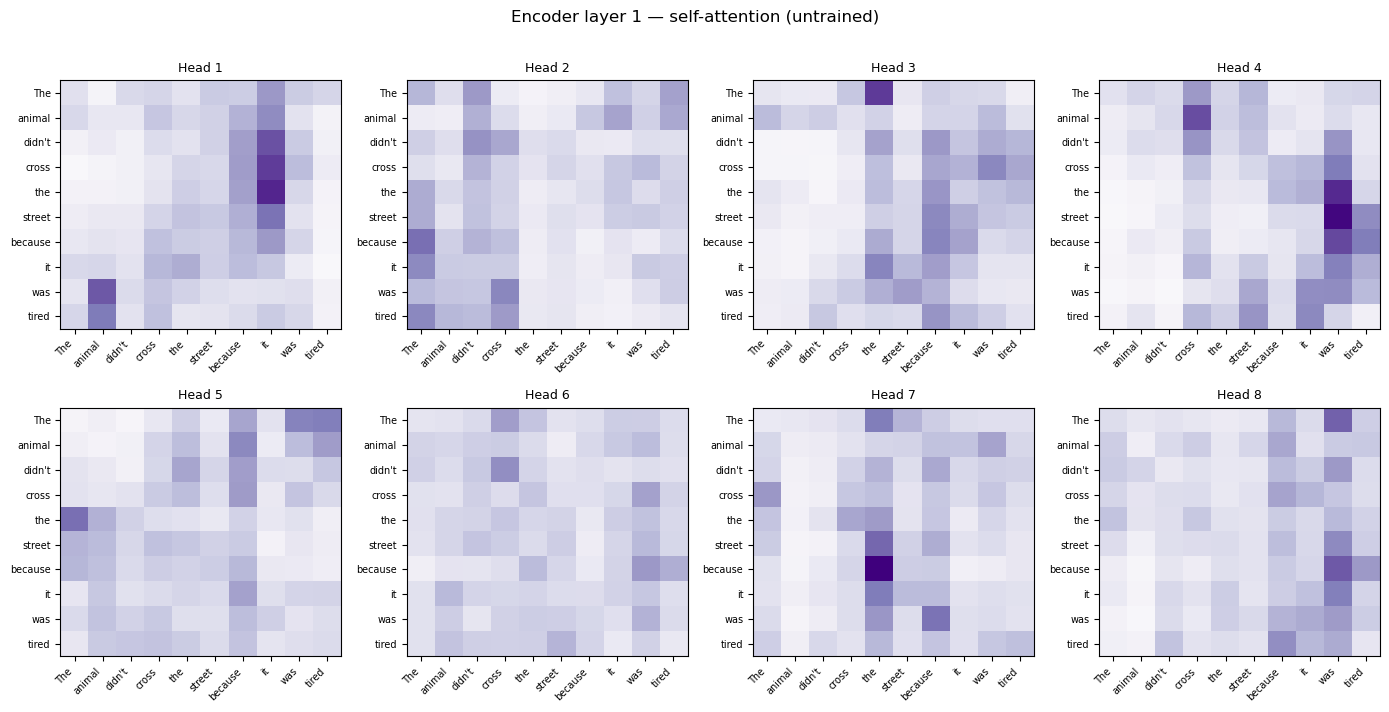

Note: weights are from an untrained model (random). Run Part 3 for meaningful patterns.


In [9]:
def visualize_attention_heads(
    attention_matrix: np.ndarray,   # (num_heads, seq_q, seq_k)
    tokens_q: list,
    tokens_k: list,
    title: str = 'Attention weights',
):
    """
    Plot one heatmap per attention head.
    Brighter cells = higher attention weight.
    """
    num_heads = attention_matrix.shape[0]
    cols = 4
    rows = math.ceil(num_heads / cols)

    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 3.5, rows * 3.5))
    axes = np.array(axes).flatten()

    cmap = plt.cm.get_cmap('Purples')
    for h in range(num_heads):
        ax = axes[h]
        im = ax.imshow(attention_matrix[h], cmap=cmap, aspect='auto',
                       vmin=0, vmax=attention_matrix.max())
        ax.set_xticks(range(len(tokens_k)))
        ax.set_yticks(range(len(tokens_q)))
        ax.set_xticklabels(tokens_k, rotation=45, ha='right', fontsize=7)
        ax.set_yticklabels(tokens_q, fontsize=7)
        ax.set_title(f'Head {h+1}', fontsize=9)

    # Hide unused subplots
    for h in range(num_heads, len(axes)):
        axes[h].set_visible(False)

    plt.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


# Demonstrate with a toy sentence using our scratch model
sentence_tokens = ['The', 'animal', 'didn\'t', 'cross', 'the', 'street', 'because', 'it', 'was', 'tired']
S = len(sentence_tokens)

# Create dummy token ids
toy_src = torch.randint(1, SRC_VOCAB, (1, S)).to(DEVICE)

model.eval()
with torch.no_grad():
    # Extract attention weights from layer 0 of the encoder
    enc_embedding = model.encoder.pos_enc(
        model.encoder.embedding(toy_src) * model.encoder.scale
    )
    src_mask = model.make_padding_mask(toy_src)
    _ = model.encoder.layers[0](enc_embedding, src_mask)
    attn_w = model.encoder.layers[0].self_attn.attn_weights  # (1, H, S, S)

attn_np = attn_w[0].cpu().numpy()  # (H, S, S)
visualize_attention_heads(attn_np, sentence_tokens, sentence_tokens,
                          title='Encoder layer 1 — self-attention (untrained)')
print('Note: weights are from an untrained model (random). Run Part 3 for meaningful patterns.')


In [10]:
from datasets import load_dataset
print("\nLoading dataset from HuggingFace…")
ds = load_dataset("somosnlp-hackathon-2022/spanish-to-quechua")
print(ds)


Loading dataset from HuggingFace…
DatasetDict({
    train: Dataset({
        features: ['es', 'qu'],
        num_rows: 102747
    })
    validation: Dataset({
        features: ['es', 'qu'],
        num_rows: 12844
    })
    test: Dataset({
        features: ['es', 'qu'],
        num_rows: 12843
    })
})


In [11]:
import pandas as pd
import unicodedata 
from datasets import Dataset as hf_Dataset


def dataset_filtrado(dataset):
    df = pd.DataFrame(dataset)
    if "translation" in df.columns:
        df["es"] = df["translation"].apply(lambda x: x["es"])
        df["qu"] = df["translation"].apply(lambda x: x["qu"])    
    df["es_words"] = df["es"].str.split().str.len()
    df["qu_words"] = df["qu"].str.split().str.len()

    df["es_chars"] = df["es"].str.len()
    df["qu_chars"] = df["qu"].str.len()

    df[["es", "qu"]].isnull().sum()

    df.drop_duplicates(inplace=True)

    #Eliminar vacios en espanol y quechua
    df = df.loc[df["es_words"] != 0]
    df = df.loc[df["qu_words"] != 0]

    #Eliminar Pares muy grandes
    df = df.loc[df["es_words"] <= 127]
    df = df.loc[df["qu_words"] <= 127]

    return hf_Dataset.from_pandas(df[['es','qu']],preserve_index=False)

# Normalize text
# each line of the file is in the format "<english>\t<french>"
# We convert text to lowercase, normalize unicode (UFKC)
def normalize(line):
    """Normalize a line of text and split into two at the tab character"""
    line = unicodedata.normalize("NFKC", line.strip().lower())
    eng, fra = line.split("\t")
    return eng.lower().strip(), fra.lower().strip()

train_data = ds["train"]
train_data = dataset_filtrado(train_data)

test_data   = ds["test"]
test_data = dataset_filtrado(test_data)

validation_data = ds["validation"]
validation_data = dataset_filtrado(validation_data)


text_pairs_train = list(zip(train_data['es'],train_data['qu']))
text_pairs_test = list(zip(test_data['es'],test_data['qu']))
text_pairs_validation = list(zip(validation_data['es'],validation_data['qu']))

for i in text_pairs_train[0:20]: 
    print(i)



('Y por último dice que el pueblo de Dios “escapará, todo el que se halle escrito en el libro ”.', 'Ichaqa chaywanpas chay tiempopim llaqtamasikikuna librasqa kanqaku. Libropi qillqasqa sutiyuqkunam lliw librakunqaku ’, nispa (Dan.')
('b) ¿Cómo lograban mantenerse estos siervos de tiempo completo?', '(2) ¿Imaynatam tukuy tiemponkuwan Diosta serviq punta cristianokunaqa mantienekuqku?')
('Cabe señalar que solo la Biblia explica de manera satisfactoria cuál es el origen de los muchos idiomas que conocemos hoy.', 'Bibliallam allintapuni willawanchik imanasqam runakunaqa kunan tiempopi achka rimayniyoq kasqankuta.')
('Pero al mismo tiempo nos advierte que “el amor al dinero es raíz de toda clase de males ”.', 'Ichaqa nintaqmi: “Qollqella kuyayqa tukuy mana allin ruraykunapa mamanmi ”, nispa.')
('Hoy, todo el que desea vivir de acuerdo con sus mandamientos considera que conmemorar el aniversario de la muerte de Cristo es de suma importancia.', 'Kay tiempopipas Cristopa kamachisqanman hina k

In [12]:
from transformers import MarianMTModel, MarianTokenizer
from tqdm import tqdm
import torch
from transformers import MarianMTModel, MarianTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

es_en_model_name = "Helsinki-NLP/opus-mt-es-en"
en_es_model_name = "Helsinki-NLP/opus-mt-en-es"

# Tokenizers
es_en_tokenizer = MarianTokenizer.from_pretrained(es_en_model_name)
en_es_tokenizer = MarianTokenizer.from_pretrained(en_es_model_name)

# Models
es_en_model = MarianMTModel.from_pretrained(es_en_model_name).to(device)
en_es_model = MarianMTModel.from_pretrained(en_es_model_name).to(device)

# Inference mode
es_en_model.eval()
en_es_model.eval()

@torch.inference_mode()
def back_translate(text):
    # Spanish -> English
    inputs = es_en_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    translated = es_en_model.generate(
        **inputs,
    )

    english = es_en_tokenizer.decode(
        translated[0],
        skip_special_tokens=True
    )

    # English -> Spanish
    inputs = en_es_tokenizer(
        english,
        return_tensors="pt",
        truncation=True,
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    translated = en_es_model.generate(
        **inputs,
    )

    spanish = en_es_tokenizer.decode(
        translated[0],
        skip_special_tokens=True
    )

    return spanish

def augment(text_pair):
  new_pair = text_pair
  for ref, qu in tqdm(text_pair):
    text = back_translate(ref)
    if text != ref:
      new_pair.append((text, qu))
  return new_pair

/venv/main/lib/python3.12/site-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

In [ ]:
# import pandas as pd

# aug_text_pairs_train = augment(text_pairs_train)

# df = pd.DataFrame(aug_text_pairs_train, columns=["es", "qu"])
# df.to_csv("translation_dataset_augmented.csv", index=False, encoding="utf-8")

# print("Saved to translation_dataset.csv")

 14%|█▍        | 13688/99291 [17:57<1:30:47, 15.71it/s]

In [ ]:
# # Two tokenizers
# import os
# import tokenizers
# # ES_TOKENIZER_PATH = os.path.join(PROJECT_DIR, "es_tokenizer.json")
# QUE_TOKENIZER_PATH = os.path.join(PROJECT_DIR, "que_tokenizer.json")
# Two tokenizers - WordLevel
def Prepare_WordLevel(text_pairs_train):
    if os.path.exists("./Wordlevel/es_tokenizer.json") and os.path.exists("./Wordlevel/que_tokenizer.json"):
        print("Cargando tokenizadores desde Google Drive...")
        es_tokenizer = tokenizers.Tokenizer.from_file("./Wordlevel/es_tokenizer.json")
        que_tokenizer = tokenizers.Tokenizer.from_file("./Wordlevel/que_tokenizer.json")

    else:

        es_tokenizer = tokenizers.Tokenizer(   tokenizers.models.WordLevel(    unk_token="[unk]"  ) )
        que_tokenizer = tokenizers.Tokenizer( tokenizers.models.WordLevel( unk_token="[unk]"    ))
        # separación por espacios
        es_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.Whitespace()
        que_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.Whitespace()

        VOCAB_SIZE = 12000

        trainer = tokenizers.trainers.WordLevelTrainer(
            vocab_size=VOCAB_SIZE,
            special_tokens=[
                "[unk]",
                "[start]",
                "[end]",
                "[pad]"
            ],
            show_progress=True
        )

        es_tokenizer.train_from_iterator( [x[0] for x in text_pairs_train], trainer=trainer )
        que_tokenizer.train_from_iterator( [x[1] for x in text_pairs_train], trainer=trainer )
        es_tokenizer.enable_padding(pad_id=es_tokenizer.token_to_id("[pad]"),pad_token="[pad]")

        que_tokenizer.enable_padding(pad_id=que_tokenizer.token_to_id("[pad]"),pad_token="[pad]")

        es_tokenizer.save("./Wordlevel/es_tokenizer.json", pretty=True)
        que_tokenizer.save("./Wordlevel/que_tokenizer.json", pretty=True)
        return es_tokenizer, que_tokenizer
        # Guardar en Drive
        # es_tokenizer.save(ES_TOKENIZER_PATH, pretty=True)
        # # que_tokenizer.save(QUE_TOKENIZER_PATH, pretty=True)

        # print("Tokenizadores guardados en Google Drive.")

In [50]:
# Two tokenizers - BPE
import os
import tokenizers
 
if os.path.exists("es_tokenizer.json") and os.path.exists("que_tokenizer.json"):
    es_tokenizer = tokenizers.Tokenizer.from_file("es_tokenizer.json")
    que_tokenizer = tokenizers.Tokenizer.from_file("que_tokenizer.json")
else:
    es_tokenizer = tokenizers.Tokenizer(tokenizers.models.BPE(unk_token="[unk]"))
    que_tokenizer = tokenizers.Tokenizer(tokenizers.models.BPE(unk_token="[unk]"))
 
    # Configure pre-tokenizer to split on whitespace and punctuation, add space at beginning of the sentence
    es_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.ByteLevel(add_prefix_space=True)
    que_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.ByteLevel(add_prefix_space=True)
 
    # Configure decoder: So that word boundary symbol "Ġ" will be removed
    es_tokenizer.decoder = tokenizers.decoders.ByteLevel()
    que_tokenizer.decoder = tokenizers.decoders.ByteLevel()
 
    # Train BPE for English and French using the same trainer
    VOCAB_SIZE = 12000
    trainer = tokenizers.trainers.BpeTrainer(
        vocab_size=VOCAB_SIZE,
        special_tokens=["[start]", "[end]", "[pad]","[unk]"],
        show_progress=True
    )
    es_tokenizer.train_from_iterator([x[0] for x in text_pairs_train], trainer=trainer)
    que_tokenizer.train_from_iterator([x[1] for x in text_pairs_train], trainer=trainer)
 
    es_tokenizer.enable_padding(pad_id=es_tokenizer.token_to_id("[pad]"), pad_token="[pad]")
    que_tokenizer.enable_padding(pad_id=que_tokenizer.token_to_id("[pad]"), pad_token="[pad]")
 
    # Save the trained tokenizers
    es_tokenizer.save("es_tokenizer.json", pretty=True)
    que_tokenizer.save("que_tokenizer.json", pretty=True)

In [12]:
# Two tokenizers - Unigram
import os
import tokenizers

if os.path.exists("es_tokenizer.json") and os.path.exists("que_tokenizer.json"):
    es_tokenizer = tokenizers.Tokenizer.from_file("es_tokenizer.json")
    que_tokenizer = tokenizers.Tokenizer.from_file("que_tokenizer.json")
else:
    # Create Unigram tokenizers
    es_tokenizer = tokenizers.Tokenizer(tokenizers.models.Unigram())
    que_tokenizer = tokenizers.Tokenizer(tokenizers.models.Unigram())

    # Configure pre-tokenizer
    es_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.ByteLevel(add_prefix_space=True)
    que_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.ByteLevel(add_prefix_space=True)

    # Configure decoder
    es_tokenizer.decoder = tokenizers.decoders.ByteLevel()
    que_tokenizer.decoder = tokenizers.decoders.ByteLevel()

    VOCAB_SIZE = 12000

    # Unigram trainer
    trainer = tokenizers.trainers.UnigramTrainer(
        vocab_size=VOCAB_SIZE,
        unk_token="[unk]",
        special_tokens=["[start]", "[end]", "[pad]", "[unk]"],
        show_progress=True,
    )

    # Train tokenizers
    es_tokenizer.train_from_iterator([x[0] for x in text_pairs_train],trainer=trainer)
    que_tokenizer.train_from_iterator([x[1] for x in text_pairs_train],trainer=trainer)

    # Enable padding
    es_tokenizer.enable_padding(pad_id=es_tokenizer.token_to_id("[pad]"),pad_token="[pad]")
    que_tokenizer.enable_padding(pad_id=que_tokenizer.token_to_id("[pad]"),pad_token="[pad]")

    # Save tokenizers
    es_tokenizer.save("es_tokenizer.json", pretty=True)
    que_tokenizer.save("que_tokenizer.json", pretty=True)

In [42]:
# #Single tokenizer
# import os
# import tokenizers
 
# if os.path.exists("es_qu_tokenizer.json"):
#     es_tokenizer = tokenizers.Tokenizer.from_file("es_qu_tokenizer.json")
#     que_tokenizer = tokenizers.Tokenizer.from_file("es_qu_tokenizer.json")
# else:
#     es_qu_tokenizer = tokenizers.Tokenizer(tokenizers.models.BPE(unk_token="[unk]"))
#     #que_tokenizer = tokenizers.Tokenizer(tokenizers.models.BPE())
 
#     # Configure pre-tokenizer to split on whitespace and punctuation, add space at beginning of the sentence
#     es_qu_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.ByteLevel(add_prefix_space=True)
#     # Configure decoder: So that word boundary symbol "Ġ" will be removed
#     es_qu_tokenizer.decoder = tokenizers.decoders.ByteLevel()

 
#     # Train BPE for English and French using the same trainer
#     VOCAB_SIZE = 24000
#     trainer = tokenizers.trainers.BpeTrainer(
#         vocab_size=VOCAB_SIZE,
#         special_tokens=["[start]", "[end]", "[pad]","[unk]"],
#         show_progress=True
#     )
#     All_text = [x[0] for x in text_pairs_train] + [x[1] for x in text_pairs_train]
    
#     es_qu_tokenizer.train_from_iterator(All_text, trainer=trainer)
    
#     #que_tokenizer.train_from_iterator([x[1] for x in text_pairs_train], trainer=trainer)
 
#     es_qu_tokenizer.enable_padding(pad_id=es_qu_tokenizer.token_to_id("[pad]"), pad_token="[pad]")
#     #que_tokenizer.enable_padding(pad_id=que_tokenizer.token_to_id("[pad]"), pad_token="[pad]")
 
#     # Save the trained tokenizers
#     es_qu_tokenizer.save("es_qu_tokenizer.json", pretty=True)
#     #que_tokenizer.save("que_tokenizer.json", pretty=True)
#     es_tokenizer = es_qu_tokenizer
#     que_tokenizer = es_qu_tokenizer

In [51]:
import numpy as np

def analyze_token_lengths(text_pairs, es_tokenizer, qu_tokenizer):
    es_lengths = []
    qu_lengths = []

    for es_text, qu_text in text_pairs:
        es_ids = es_tokenizer.encode(es_text).ids
        qu_ids = qu_tokenizer.encode(qu_text).ids

        es_lengths.append(len(es_ids))
        qu_lengths.append(len(qu_ids))

    es_lengths = np.array(es_lengths)
    qu_lengths = np.array(qu_lengths)

    print("=" * 50)
    print("SPANISH")
    print("=" * 50)
    print(f"Mean length        : {es_lengths.mean():.2f}")
    print(f"Median length      : {np.median(es_lengths):.2f}")
    print(f"95th percentile    : {np.percentile(es_lengths, 95):.2f}")
    print(f"99th percentile    : {np.percentile(es_lengths, 99):.2f}")
    print(f"Maximum length     : {es_lengths.max()}")

    print("\n")

    print("=" * 50)
    print("QUECHUA")
    print("=" * 50)
    print(f"Mean length        : {qu_lengths.mean():.2f}")
    print(f"Median length      : {np.median(qu_lengths):.2f}")
    print(f"95th percentile    : {np.percentile(qu_lengths, 95):.2f}")
    print(f"99th percentile    : {np.percentile(qu_lengths, 99):.2f}")
    print(f"Maximum length     : {qu_lengths.max()}")

    print("\n")

    print("=" * 50)
    print("SEQUENCES > 128 TOKENS")
    print("=" * 50)
    print(f"Spanish : {(es_lengths > 128).sum()} / {len(es_lengths)}")
    print(f"Quechua : {(qu_lengths > 128).sum()} / {len(qu_lengths)}")

    return es_lengths, qu_lengths


# Run on training set
es_lengths, qu_lengths = analyze_token_lengths(
    text_pairs_train,
    es_tokenizer,
    que_tokenizer
)

SPANISH
Mean length        : 19.10
Median length      : 17.00
95th percentile    : 39.00
99th percentile    : 55.00
Maximum length     : 132


QUECHUA
Mean length        : 14.47
Median length      : 13.00
95th percentile    : 30.00
99th percentile    : 43.00
Maximum length     : 111


SEQUENCES > 128 TOKENS
Spanish : 2 / 99291
Quechua : 0 / 99291


In [52]:
fr_sample = "Hola como estas ?"
encoded = es_tokenizer.encode("[start] " + fr_sample + " [end]")
print(f"Original: {fr_sample}")
print(f"Tokens: {encoded.tokens}")
print(f"IDs: {encoded.ids}")

print(f"Decoded: {es_tokenizer.decode(encoded.ids)}")

Original: Hola como estas ?
Tokens: ['[start]', 'ĠH', 'ola', 'Ġcomo', 'Ġestas', 'Ġ', '?', 'Ġ', '[end]']
IDs: [0, 438, 2548, 316, 920, 116, 28, 116, 1]
Decoded:  Hola como estas ? 


In [71]:
import torch
from torch.utils.data import Dataset, DataLoader
 
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, text_pairs):
        self.text_pairs = text_pairs
 
    def __len__(self):
        return len(self.text_pairs)
 
    def __getitem__(self, idx):
        es, que = self.text_pairs[idx]
        return es, "[start] " + que + " [end]"
 
 
def collate_fn(batch):
    es_str, que_str = zip(*batch)
    es_enc = es_tokenizer.encode_batch(es_str, add_special_tokens=True)
    que_enc = que_tokenizer.encode_batch(que_str, add_special_tokens=True)
    es_ids = [enc.ids for enc in es_enc]
    que_ids = [enc.ids for enc in que_enc]
    return torch.tensor(es_ids), torch.tensor(que_ids)
 

In [ ]:
import sacrebleu
def train_one_epoch(model, loader, device):
    model.train()
    skips = 0
    epoch_loss = 0 
    for es_ids, que_ids in loader:
        # Move the "sentences" to device
        es_ids = es_ids.to(device)
        que_ids = que_ids.to(device)
        if es_ids.shape[1] >= 128:
            skips += 1
            continue
        # zero the grad, then forward pass
        optimizer.zero_grad()
        outputs = model(es_ids, que_ids)    
        # compute the loss: compare 3D logits to 2D targets
        loss = loss_fn(outputs[:, :-1, :].reshape(-1, outputs.shape[-1]), que_ids[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.CLIP_GRAD, error_if_nonfinite=False)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()                    
    return epoch_loss, skips

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    skips = 0
    val_loss =  0
    for es_ids, que_ids in loader:
        # Move the "sentences" to device
        es_ids = es_ids.to(device)
        que_ids = que_ids.to(device)
        if es_ids.shape[1] >= 128:
            skips += 1
            continue
        # zero the grad, then forward pass
        outputs = model(es_ids, que_ids)    
        # compute the loss: compare 3D logits to 2D targets
        loss = loss_fn(outputs[:, :-1, :].reshape(-1, outputs.shape[-1]), que_ids[:, 1:].reshape(-1))
        val_loss += loss.item()  
    return val_loss, skips    



def create_causal_mask(seq_len, device):
    mask = torch.triu(torch.full((seq_len, seq_len), float('-inf'), device=device), diagonal=1)
    return mask


@torch.no_grad()
def Calculate_BLEU(model, loader, device, beam_size=4, max_len=60):
    model.eval()
    skips = 0
    hypotheses = []
    references = []
    for es, ref in loader:
        es_ids = torch.tensor(es_tokenizer.encode(es).ids).unsqueeze(0).to(device)
        if es_ids.shape[1] >= 128:
            skips += 1
            continue        
        start_id = que_tokenizer.token_to_id("[start]")
        end_id   = que_tokenizer.token_to_id("[end]")
        pad_es   = es_tokenizer.token_to_id("[pad]")
        pad_que  = que_tokenizer.token_to_id("[pad]")
    
        src_mask = model.make_padding_mask(es_ids, pad_es)
        enc_out  = model.encoder(es_ids, src_mask)
        
        # Each beam: (score, token_ids)
        beams = [(0.0, [start_id])]
        completed = []
        
        

        for _ in range(max_len):
            candidates = []
            for score, ids in beams:
                if ids[-1] == end_id:
                    completed.append((score, ids))
                    continue
                tgt = torch.tensor([ids], device=es_ids.device)
                T = tgt.shape[1]
                causal  = model.make_causal_mask(T, es_ids.device)
                tgt_pad = model.make_padding_mask(tgt, pad_que)
                dec_out = model.decoder(tgt, enc_out, src_mask, causal & tgt_pad)
                logits  = model.output_proj(dec_out[:, -1, :])
                log_probs = torch.log_softmax(logits, dim=-1)[0]
                topk = log_probs.topk(beam_size)
                for lp, tok in zip(topk.values, topk.indices):
                    candidates.append((score + lp.item(), ids + [tok.item()]))
    
            if not candidates:
                break
            candidates.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
            beams = candidates[:beam_size]
    
        completed += beams
        completed.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
        
        hyp = que_tokenizer.decode(completed[0][1])
        hypotheses.append(hyp)
        references.append(ref)
    bleu = sacrebleu.corpus_bleu(hypotheses, [references])
    return bleu.score, skips

def create_padding_mask(batch, padding_token_id):
    batch_size, seq_len = batch.shape
    device = batch.device
    padded = torch.zeros_like(batch, device=device).float().masked_fill(batch == padding_token_id, float('-inf'))
    mask = torch.zeros(batch_size, seq_len, seq_len, device=device) + padded[:,:,None] + padded[:,None,:]
    return mask[:, None, :, :]

class Config:
    # Model
    D_MODEL     = 256
    NUM_HEADS   = 4
    D_FF        = 1024
    NUM_LAYERS  = 4
    DROPOUT     = 0.2
    MAX_LEN     = 128       # max sequence length (tokens)

    # Training
    EPOCHS          = 400
    BATCH_SIZE      = 32
    WARMUP_STEPS    = 1000
    LABEL_SMOOTHING = 0.15
    CLIP_GRAD       = 1.0

    # # Vocab
    # MAX_VOCAB       = 16000  # per language
    # PAD_IDX         = 0
    # SOS_IDX         = 1
    # EOS_IDX         = 2
    # UNK_IDX         = 3

    # Checkpointing
    CHECKPOINT_DIR  = "checkpoints"
    HISTORY_FILE    = "training_history.json"
    PLOT_FILE       = "training_history.png"

def load_checkpoint(path, model, optimizer, scheduler, scaler=None):
    checkpoint = torch.load(path, map_location="cpu")  # safer to load to CPU first

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    if scaler and "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    start_epoch = checkpoint["epoch"] + 1  # resume from NEXT epoch
    start_step = checkpoint["step"]
    loss = checkpoint["loss"]

    return start_epoch, start_step, loss
import pandas as pd

def save_losses_to_csv(train_losses, val_losses, filename="losses.csv"):
    """
    Save train and validation losses to a CSV file.

    Parameters
    ----------
    train_losses : list
        List of training losses.
    val_losses : list
        List of validation losses.
    filename : str
        Output CSV filename.
    """
    max_len = max(len(train_losses), len(val_losses))

    # Pad shorter list with None
    train_losses = train_losses + [None] * (max_len - len(train_losses))
    val_losses = val_losses + [None] * (max_len - len(val_losses))

    df = pd.DataFrame({
        "epoch": range(1, max_len + 1),
        "train_loss": train_losses,
        "val_loss": val_losses
    })

    df.to_csv(filename, index=False)
    print(f"Saved losses to {filename}")
    
def save_checkpoint(model, optimizer, scheduler, epoch, step, loss, path="checkpoint.pt"):
    checkpoint = {
        "epoch": epoch,
        "step": step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "loss": loss,
    }
    # # If using AMP (mixed precision)
    # if scaler is not None:
    #     checkpoint["scaler_state_dict"] = scaler.state_dict()

    torch.save(checkpoint, path)
    print(f"Checkpoint saved at epoch {epoch}, step {step}")


cfg = Config()
#Dataset
dataset_train = TranslationDataset(text_pairs_train)
dataloader_train = DataLoader(dataset_train, batch_size=cfg.BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

dataset_test = TranslationDataset(text_pairs_test)
dataloader_test = DataLoader(dataset_test, batch_size=cfg.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

dataset_validation = TranslationDataset(text_pairs_validation)
dataloader_validation = DataLoader(dataset_validation, batch_size=cfg.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)



model = Transformer(
    src_vocab_size = len(es_tokenizer.get_vocab()),
    tgt_vocab_size = len(que_tokenizer.get_vocab()),
    d_model        = cfg.D_MODEL,
    num_heads      = cfg.NUM_HEADS,
    d_ff           = cfg.D_FF,
    num_layers     = cfg.NUM_LAYERS,
    dropout        = cfg.DROPOUT,
    max_len        = cfg.MAX_LEN,
).to(DEVICE)

loss_fn = nn.CrossEntropyLoss(ignore_index=que_tokenizer.token_to_id("[pad]"),label_smoothing=cfg.LABEL_SMOOTHING)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.98), eps=1e-9,weight_decay=1e-5)


warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=cfg.WARMUP_STEPS)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS * len(dataloader_train) - cfg.WARMUP_STEPS, eta_min=1e-5)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[cfg.WARMUP_STEPS])

train_losses, val_losses, BLEU = [], [], []

Best_val_loss = 100
start_epoch = 0
global_step = 0
CHECKPOINT_PATH = "checkpoint.pt"
# Resume if checkpoint exists
if os.path.exists(CHECKPOINT_PATH):
    print("Resuming from checkpoint...")
    start_epoch, global_step, last_loss = load_checkpoint(
        CHECKPOINT_PATH, model, optimizer, scheduler
    )

for epoch in range(start_epoch, cfg.EPOCHS):
    bleu_score = 0
    global_step += 1
    start = time.time()
    train_loss, _ = train_one_epoch(model,dataloader_train, DEVICE)
    val_loss, _ = validate(model, dataloader_test, DEVICE)
    end = time.time()

    if epoch % 50 == 0 and epoch != 0:
        bleu_score, _ = Calculate_BLEU(model, text_pairs_validation[0:125], DEVICE)
        BLEU.append(bleu_score)
    
    train_losses.append(train_loss/len(dataloader_train))
    val_losses.append(val_loss/len(dataloader_test))
    
    if val_loss/len(dataloader_test) < Best_val_loss:
        save_checkpoint(model, optimizer, scheduler, epoch, global_step, train_loss)
        torch.save({'epoch': epoch, 'model_state': model.state_dict()},f"Best_model.pth")
        Best_val_loss = val_loss/len(dataloader_test)
     
    print(f"Epoch {epoch+1}/{cfg.EPOCHS} | LR {optimizer.param_groups[0]['lr']:.6f} | "
          f"Train loss {train_loss/len(dataloader_train):.4f} | "
          f"Val loss {val_loss/len(dataloader_test):.4f} | "
          f"Time {end-start:.1f}s")
save_losses_to_csv(train_losses,val_losses, "Unigram.csv" )


In [58]:
model_BPE = Transformer(
    src_vocab_size = len(es_tokenizer.get_vocab()),
    tgt_vocab_size = len(que_tokenizer.get_vocab()),
    d_model        = cfg.D_MODEL,
    num_heads      = cfg.NUM_HEADS,
    d_ff           = cfg.D_FF,
    num_layers     = cfg.NUM_LAYERS,
    dropout        = cfg.DROPOUT,
    max_len        = cfg.MAX_LEN,
).to(DEVICE)
model_BPE.load_state_dict(torch.load("./BPE/Best_model.pth", weights_only=True)['model_state'])
model_BPE.eval()

model_unigram = Transformer(
    src_vocab_size = len(es_tokenizer.get_vocab()),
    tgt_vocab_size = len(que_tokenizer.get_vocab()),
    d_model        = cfg.D_MODEL,
    num_heads      = cfg.NUM_HEADS,
    d_ff           = cfg.D_FF,
    num_layers     = cfg.NUM_LAYERS,
    dropout        = cfg.DROPOUT,
    max_len        = cfg.MAX_LEN,
).to(DEVICE)
model_unigram.load_state_dict(torch.load("./Unigram/Best_model.pth", weights_only=True)['model_state'])
model_unigram.eval()

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(12000, 256, padding_idx=0)
    (pos_enc): PositionalEncoding(
      (dropout): Dropout(p=0.2, inplace=False)
    )
    (layers): ModuleList(
      (0-3): 4 x EncoderLayer(
        (self_attn): MultiHeadAttention(
          (W_q): Linear(in_features=256, out_features=256, bias=False)
          (W_k): Linear(in_features=256, out_features=256, bias=False)
          (W_v): Linear(in_features=256, out_features=256, bias=False)
          (W_o): Linear(in_features=256, out_features=256, bias=False)
          (dropout): Dropout(p=0.2, inplace=False)
        )
        (ffn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=256, out_features=1024, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.2, inplace=False)
            (3): Linear(in_features=1024, out_features=256, bias=True)
          )
        )
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)

In [59]:
model_BPE.eval()
N_SAMPLES = 5
MAX_LEN = 128

def Traducir(Espanol):
    with torch.no_grad():
        start_token_id = que_tokenizer.token_to_id("[start]")
        pad_es_id      = es_tokenizer.token_to_id("[pad]")
        pad_que_id     = que_tokenizer.token_to_id("[pad]")
        end_token_id   = que_tokenizer.token_to_id("[end]")

        for es in [Espanol]:
            es_ids = torch.tensor(es_tokenizer.encode(es).ids).unsqueeze(0).to(DEVICE)

            # ── Encoder ──────────────────────────────────────────────────────────
            # Use the full encoder forward (includes pos_enc + scale + norm)
            src_mask = model.make_padding_mask(es_ids, pad_es_id)   # (1,1,1,S_src)
            enc_out  = model.encoder(es_ids, src_mask)               # (1, S_src, d)

            # ── Decoder (autoregressive) ──────────────────────────────────────────
            que_ids = torch.tensor([[start_token_id]], device=DEVICE)  # (1, 1)

            for _ in range(MAX_LEN):
                tgt_len = que_ids.shape[1]

                # Causal mask over the growing target sequence
                causal_mask  = model.make_causal_mask(tgt_len, DEVICE)          # (1,1,T,T)
                tgt_pad_mask = model.make_padding_mask(que_ids, pad_que_id)      # (1,1,1,T)
                tgt_mask     = causal_mask & tgt_pad_mask                        # (1,1,T,T)

                # src_mask for cross-attention stays the same as the encoder src_mask
                dec_out  = model.decoder(que_ids, enc_out, src_mask, tgt_mask)   # (1,T,d)
                logits   = model.output_proj(dec_out)                            # (1,T,V)

                next_id  = logits[:, -1, :].argmax(dim=-1, keepdim=True)        # (1,1)
                que_ids  = torch.cat([que_ids, next_id], dim=1)

                if next_id.item() == end_token_id:
                    break

            # pred_que = que_tokenizer.decode(que_ids[0].tolist())
            return que_tokenizer.decode(que_ids[0].tolist())
            # print(f"Espanol  : {es}")
            # print(f"Quechua   : {true_que}")
            # print(f"Predicted: {pred_que}\n")
            
@torch.no_grad()
def beam_decode(model, es_ids, beam_size=4, max_len=60):
    start_id = que_tokenizer.token_to_id("[start]")
    end_id   = que_tokenizer.token_to_id("[end]")
    pad_es   = es_tokenizer.token_to_id("[pad]")
    pad_que  = que_tokenizer.token_to_id("[pad]")

    src_mask = model.make_padding_mask(es_ids, pad_es)
    if es_ids.shape[1] >= 128:
        return  ""  
    enc_out  = model.encoder(es_ids, src_mask)

    # Each beam: (score, token_ids)
    beams = [(0.0, [start_id])]
    completed = []

    for _ in range(max_len):
        candidates = []
        for score, ids in beams:
            if ids[-1] == end_id:
                completed.append((score, ids))
                continue
            tgt = torch.tensor([ids], device=es_ids.device)
            T = tgt.shape[1]
            causal  = model.make_causal_mask(T, es_ids.device)
            tgt_pad = model.make_padding_mask(tgt, pad_que)
            dec_out = model.decoder(tgt, enc_out, src_mask, causal & tgt_pad)
            logits  = model.output_proj(dec_out[:, -1, :])
            log_probs = torch.log_softmax(logits, dim=-1)[0]
            topk = log_probs.topk(beam_size)
            for lp, tok in zip(topk.values, topk.indices):
                candidates.append((score + lp.item(), ids + [tok.item()]))

        if not candidates:
            break
        candidates.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
        beams = candidates[:beam_size]

    completed += beams
    completed.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
    return completed[0][1]            

In [ ]:
import torch
import sacrebleu
from tqdm import tqdm

# ─────────────────────────────────────────────
# Pre-cache all special token IDs once globally
# ─────────────────────────────────────────────
_START_ID = None
_END_ID   = None
_PAD_ES   = None
_PAD_QUE  = None

def _init_token_ids():
    global _START_ID, _END_ID, _PAD_ES, _PAD_QUE
    if _START_ID is None:
        _START_ID = que_tokenizer.token_to_id("[start]")
        _END_ID   = que_tokenizer.token_to_id("[end]")
        _PAD_ES   = es_tokenizer.token_to_id("[pad]")
        _PAD_QUE  = que_tokenizer.token_to_id("[pad]")


@torch.no_grad()
def beam_decode(model, es_ids, beam_size=4, max_len=60):
    """
    Optimized beam decoder.

    Key changes vs original:
    - Token IDs are cached after the first call (no dict lookup per call).
    - All active beams are stacked into a single tensor and decoded in ONE
      batched forward pass per timestep (beam_size × seq_len) instead of
      beam_size separate passes.
    - Candidate selection uses torch.topk on a flat GPU tensor instead of
      sorting a Python list, keeping work on the GPU.
    - Early exit when every beam has produced [end].
    """
    _init_token_ids()

    # Reject sequences that would exceed the positional embedding table
    if es_ids.shape[1] >= 128:
        return []

    device = es_ids.device

    # Encoder runs exactly once per source sentence
    src_mask = model.make_padding_mask(es_ids, _PAD_ES)
    enc_out  = model.encoder(es_ids, src_mask)          # (1, S, d_model)

    # ── initialise beams ──────────────────────────────────────────────────
    # Each beam: (cumulative_log_prob, [token_ids])
    beams: list[tuple[float, list[int]]] = [(0.0, [_START_ID])]
    completed: list[tuple[float, list[int]]] = []

    for _ in range(max_len):
        # Separate finished beams from active ones
        active, newly_done = [], []
        for score, ids in beams:
            (newly_done if ids[-1] == _END_ID else active).append((score, ids))
        completed.extend(newly_done)

        if not active:
            break

        # ── batched decoder forward pass ───────────────────────────────
        # Stack all active beam sequences into (B, T) where B = len(active)
        max_t  = max(len(ids) for _, ids in active)
        tgt    = torch.full((len(active), max_t), _PAD_QUE,
                            dtype=torch.long, device=device)
        for i, (_, ids) in enumerate(active):
            tgt[i, :len(ids)] = torch.tensor(ids, dtype=torch.long)

        T       = tgt.shape[1]
        causal  = model.make_causal_mask(T, device)         # (T, T)
        tgt_pad = model.make_padding_mask(tgt, _PAD_QUE)    # (B, 1, 1, T)

        # Expand encoder output to match batch size of active beams
        enc_expanded = enc_out.expand(len(active), -1, -1)  # (B, S, d)
        src_mask_exp = src_mask.expand(len(active), -1, -1, -1)

        dec_out   = model.decoder(tgt, enc_expanded, src_mask_exp,
                                  causal & tgt_pad)          # (B, T, d)
        logits    = model.output_proj(dec_out[:, -1, :])     # (B, V)
        log_probs = torch.log_softmax(logits, dim=-1)        # (B, V)

        # ── top-k expansion (on GPU) ────────────────────────────────────
        topk_vals, topk_ids = log_probs.topk(beam_size, dim=-1)  # (B, K)

        candidates: list[tuple[float, list[int]]] = []
        for b, (score, ids) in enumerate(active):
            for k in range(beam_size):
                new_score = score + topk_vals[b, k].item()
                new_ids   = ids + [topk_ids[b, k].item()]
                candidates.append((new_score, new_ids))

        if not candidates:
            break

        # Length-normalised selection — sort once, keep top beam_size
        candidates.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
        beams = candidates[:beam_size]

    completed.extend(beams)
    if not completed:
        return []

    completed.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
    return completed[0][1]


# ─────────────────────────────────────────────
# Evaluation loop
# ─────────────────────────────────────────────

EVAL_PAIRS = [
    (
        'Pero ¿qué piensa de este mundo, es decir, de la sociedad humana injusta alejada de Dios?',
        'Ichaqa, ¿imatam piensanki Diosmanta karunchasqa mana allin ruraq runakunamanta?'
    ),
    (
        '¿Cómo debe verse la paternidad, y por qué?',
        '¿Imaynatam qawana tayta - mama kayta, hinaspa imanasqa?'
    ),
    (
        '"Hablar aliviaba la angustia que sentía ", recuerda.',
        'Chaymi nin: "Willakusqaywanmi hawkayayta tarirqani ", nispa.'
    ),
    (
        'La revista Maclean\'s resume así la opinión de un conocido ateo: "Este concepto cristiano — la existencia de algo que ni la ciencia puede explicar ni nuestros sentidos percibir — [...] le resta valor a la única vida con que contamos y nos hace más propensos a la violencia ".',
        'Diospi mana iñiq reqsisqa runapa nisqanmantam huk revista nin: "Diospi iñiyqa [...] vidanchiktam yanqachan hinaspam maqanakuyman tanqawanchik ", nispa.'
    ),
    (
        'Anímelo a expresar su postura.',
        'Kallpanchay imayna piensasqanmanta willasunaykipaq.'
    ),
]

def run_evaluation(model = None, text_pairs=None, experiment_name="Transformer_BPE_256"):
    """
    Evaluate translations with the optimised beam decoder.

    Args:
        text_pairs: iterable of (src, ref) pairs. Defaults to EVAL_PAIRS.
        experiment_name: label passed to save_evaluation_scores.
    """
    if text_pairs is None:
        text_pairs = text_pairs_validation  # noqa: F821 – defined in calling scope

    hypotheses: list[str] = []
    references:  list[str] = []
    data:        list[dict] = []

    _init_token_ids()   # warm the cache before the loop

    print("Evaluating translations...")
    for src, ref in tqdm(text_pairs):
        es_ids = (
            torch.tensor(es_tokenizer.encode(src).ids)   # noqa: F821
                 .unsqueeze(0)
                 .to(DEVICE)                              # noqa: F821
        )

        token_ids = beam_decode(model, es_ids)            # noqa: F821
        hyp = que_tokenizer.decode(token_ids)             # noqa: F821

        data.append({"src": src, "mt": hyp, "ref": ref})
        hypotheses.append(hyp)
        references.append(ref)

    scores = save_evaluation_scores(                      # noqa: F821
        csv_path="translation_results_2.csv",
        hypotheses=hypotheses,
        references=references,
        comet_model=comet_model,                          # noqa: F821
        data=data,
        experiment_name=experiment_name,
    )
    print(scores)
    return scores


In [25]:
def save_evaluation_scores(
    csv_path,
    hypotheses,
    references,
    comet_model=None,
    data=None,
    experiment_name=None,
):
    """
    Compute BLEU, chrF++, COMET and save results to CSV.

    Parameters
    ----------
    csv_path : str
        Output CSV file.
    hypotheses : list[str]
        Model translations.
    references : list[str]
        Reference translations.
    comet_model : COMET model, optional
        Loaded COMET model.
    data : list[dict], optional
        COMET input format:
        [{"src": ..., "mt": ..., "ref": ...}, ...]
    experiment_name : str, optional
        Name of the experiment/run.
    """

    # BLEU
    bleu = sacrebleu.corpus_bleu(hypotheses, [references])

    # chrF++
    chrfpp = sacrebleu.corpus_chrf(
        hypotheses,
        [references],
        word_order=2
    )

    # COMET
    comet_score = None
    if comet_model is not None and data is not None:
        result = comet_model.predict(
            data,
            batch_size=8,
            gpus=1 if torch.cuda.is_available() else 0
        )
        comet_score = result.system_score

    row = {
        "experiment": experiment_name,
        "BLEU": bleu.score,
        "chrF++": chrfpp.score,
        "COMET": comet_score,
        "BLEU_1gram": bleu.precisions[0],
        "BLEU_2gram": bleu.precisions[1],
        "BLEU_3gram": bleu.precisions[2],
        "BLEU_4gram": bleu.precisions[3],
        "BP": bleu.bp,
    }

    df_new = pd.DataFrame([row])

    if os.path.exists(csv_path):
        df_old = pd.read_csv(csv_path)
        df = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df = df_new

    df.to_csv(csv_path, index=False)

    return row

In [24]:
from comet import download_model, load_from_checkpoint
# --------------------------------------------------
# 1. Load COMET model
# --------------------------------------------------

model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(model_path)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\rrive\anaconda3\Lib\site-packages\lightning_fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Lightning automatically upgraded your loaded checkpoint fr

In [89]:
# Two tokenizers - BPE
import os
import tokenizers
 
if os.path.exists("./BPE/es_tokenizer.json") and os.path.exists("./BPE/que_tokenizer.json"):
    es_tokenizer = tokenizers.Tokenizer.from_file("./BPE/es_tokenizer.json")
    que_tokenizer = tokenizers.Tokenizer.from_file("./BPE/que_tokenizer.json")
else:
    es_tokenizer = tokenizers.Tokenizer(tokenizers.models.BPE(unk_token="[unk]"))
    que_tokenizer = tokenizers.Tokenizer(tokenizers.models.BPE(unk_token="[unk]"))
 
    # Configure pre-tokenizer to split on whitespace and punctuation, add space at beginning of the sentence
    es_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.ByteLevel(add_prefix_space=True)
    que_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.ByteLevel(add_prefix_space=True)
 
    # Configure decoder: So that word boundary symbol "Ġ" will be removed
    es_tokenizer.decoder = tokenizers.decoders.ByteLevel()
    que_tokenizer.decoder = tokenizers.decoders.ByteLevel()
 
    # Train BPE for English and French using the same trainer
    VOCAB_SIZE = 12000
    trainer = tokenizers.trainers.BpeTrainer(
        vocab_size=VOCAB_SIZE,
        special_tokens=["[start]", "[end]", "[pad]","[unk]"],
        show_progress=True
    )
    es_tokenizer.train_from_iterator([x[0] for x in text_pairs_train], trainer=trainer)
    que_tokenizer.train_from_iterator([x[1] for x in text_pairs_train], trainer=trainer)
 
    es_tokenizer.enable_padding(pad_id=es_tokenizer.token_to_id("[pad]"), pad_token="[pad]")
    que_tokenizer.enable_padding(pad_id=que_tokenizer.token_to_id("[pad]"), pad_token="[pad]")
 
    # Save the trained tokenizers
    es_tokenizer.save("es_tokenizer.json", pretty=True)
    que_tokenizer.save("que_tokenizer.json", pretty=True)

In [92]:
import sacrebleu
from tqdm import tqdm
hypotheses = []
references  = []
data = []
EVAL_PAIRS = [
    (
        'Pero ¿qué piensa de este mundo, es decir, de la sociedad humana injusta alejada de Dios?',
        'Ichaqa, ¿imatam piensanki Diosmanta karunchasqa mana allin ruraq runakunamanta?'
    ),
    (
        '¿Cómo debe verse la paternidad, y por qué?',
        '¿Imaynatam qawana tayta - mama kayta, hinaspa imanasqa?'
    ),
    (
        '“Hablar aliviaba la angustia que sentía ”, recuerda.',
        'Chaymi nin: “Willakusqaywanmi hawkayayta tarirqani ”, nispa.'
    ),
    (
        'La revista Maclean’s resume así la opinión de un conocido ateo: “Este concepto cristiano — la existencia de algo que ni la ciencia puede explicar ni nuestros sentidos percibir — [...] le resta valor a la única vida con que contamos y nos hace más propensos a la violencia ”.',
        'Diospi mana iñiq reqsisqa runapa nisqanmantam huk revista nin: “Diospi iñiyqa [...] vidanchiktam yanqachan hinaspam maqanakuyman tanqawanchik ”, nispa.'
    ),
    (
        'Anímelo a expresar su postura.',
        'Kallpanchay imayna piensasqanmanta willasunaykipaq.'
    ),
    (
        'Hola como estas ?',
        'Allinllachu, imaynallam ?'
    )
]
print('Evaluating translations...')
for src, ref in EVAL_PAIRS:
    
    es_ids = torch.tensor(es_tokenizer.encode(src).ids).unsqueeze(0).to(DEVICE)
    token_ids = beam_decode(model_BPE, es_ids)
    hyp = que_tokenizer.decode(token_ids)
    data.append({"src": src, "mt": hyp, "ref": ref})
    hypotheses.append(hyp)
    references.append(ref)
    print(f'  SRC: {src}')
    print(f'  HYP: {hyp}')
    print(f'  REF: {ref}')
    print()

time.sleep(1)
# Corpus BLEU
bleu = sacrebleu.corpus_bleu(hypotheses, [references])
chrfpp = sacrebleu.corpus_chrf(hypotheses, [references],word_order=2)
result = comet_model.predict(data, batch_size=8, gpus=1 if torch.cuda.is_available() else 0)
print(f'\n{"=" * 50}')
# print(f"COMET score: {result.system_score:.4f}")
print(f'Corpus BLEU score : {bleu.score:.2f}')
print(f"chrF score: {chrfpp.score:.2f}")
print(f'1-gram precision  : {bleu.precisions[0]:.2f}')
print(f'2-gram precision  : {bleu.precisions[1]:.2f}')
print(f'3-gram precision  : {bleu.precisions[2]:.2f}')
print(f'4-gram precision  : {bleu.precisions[3]:.2f}')
print(f'Brevity penalty   : {bleu.bp:.4f}')
print(f'{"=" * 50}')
print()
print('BLEU scale reference:')
print('  < 10  : Almost useless')
print('  10–19 : Hard to convey the gist')
print('  20–29 : Understandable, significant errors')
print('  30–40 : Intelligible, some mistakes')
print('  40–50 : High quality translation')
print('  50–60 : Very high quality, close to human')
print('  > 60  : Superior to human')

# scores = save_evaluation_scores(
#     csv_path="translation_results.csv",
#     hypotheses=hypotheses,
#     references=references,
#     comet_model=comet_model,
#     data=data,
#     experiment_name="Transformer_BPE_256"
# )

# print(scores)

Evaluating translations...
  SRC: Pero ¿qué piensa de este mundo, es decir, de la sociedad humana injusta alejada de Dios?
  HYP:  Ichaqa, ¿imatam piensanku mana allin ruraq runakuna Diosmanta karunchakusqankuta? 
  REF: Ichaqa, ¿imatam piensanki Diosmanta karunchasqa mana allin ruraq runakunamanta?

  SRC: ¿Cómo debe verse la paternidad, y por qué?
  HYP: arinapaqqa, ¿imaynatam qawananchik hinaspa imanasqa? 
  REF: ¿Imaynatam qawana tayta - mama kayta, hinaspa imanasqa?

  SRC: “Hablar aliviaba la angustia que sentía ”, recuerda.
  HYP: mi nin: “Mayna llakisqa tarikuspaymi hukmanyasqa tarikurqani ”, nispa. 
  REF: Chaymi nin: “Willakusqaywanmi hawkayayta tarirqani ”, nispa.

  SRC: La revista Maclean’s resume así la opinión de un conocido ateo: “Este concepto cristiano — la existencia de algo que ni la ciencia puede explicar ni nuestros sentidos percibir — [...] le resta valor a la única vida con que contamos y nos hace más propensos a la violencia ”.
  HYP:  Mleans sutiyoq revistapim

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  5.06it/s]



Corpus BLEU score : 19.51
chrF score: 44.24
1-gram precision  : 43.06
2-gram precision  : 27.27
3-gram precision  : 16.67
4-gram precision  : 7.41
Brevity penalty   : 1.0000

BLEU scale reference:
  < 10  : Almost useless
  10–19 : Hard to convey the gist
  20–29 : Understandable, significant errors
  30–40 : Intelligible, some mistakes
  40–50 : High quality translation
  50–60 : Very high quality, close to human
  > 60  : Superior to human


In [ ]:
run_evaluation(model = model_BPE,text_pairs=None, experiment_name="Transformer_BPE_BPE_256")

In [65]:
# Two tokenizers - Unigram
import os
import tokenizers

if os.path.exists("./Unigram/es_tokenizer.json") and os.path.exists("./Unigram/que_tokenizer.json"):
    es_tokenizer = tokenizers.Tokenizer.from_file("./Unigram/es_tokenizer.json")
    que_tokenizer = tokenizers.Tokenizer.from_file("./Unigram/que_tokenizer.json")
else:
    # Create Unigram tokenizers
    es_tokenizer = tokenizers.Tokenizer(tokenizers.models.Unigram())
    que_tokenizer = tokenizers.Tokenizer(tokenizers.models.Unigram())

    # Configure pre-tokenizer
    es_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.ByteLevel(add_prefix_space=True)
    que_tokenizer.pre_tokenizer = tokenizers.pre_tokenizers.ByteLevel(add_prefix_space=True)

    # Configure decoder
    es_tokenizer.decoder = tokenizers.decoders.ByteLevel()
    que_tokenizer.decoder = tokenizers.decoders.ByteLevel()

    VOCAB_SIZE = 12000

    # Unigram trainer
    trainer = tokenizers.trainers.UnigramTrainer(
        vocab_size=VOCAB_SIZE,
        unk_token="[unk]",
        special_tokens=["[start]", "[end]", "[pad]", "[unk]"],
        show_progress=True,
    )

    # Train tokenizers
    es_tokenizer.train_from_iterator([x[0] for x in text_pairs_train],trainer=trainer)
    que_tokenizer.train_from_iterator([x[1] for x in text_pairs_train],trainer=trainer)

    # Enable padding
    es_tokenizer.enable_padding(pad_id=es_tokenizer.token_to_id("[pad]"),pad_token="[pad]")
    que_tokenizer.enable_padding(pad_id=que_tokenizer.token_to_id("[pad]"),pad_token="[pad]")

    # Save tokenizers
    es_tokenizer.save("es_tokenizer.json", pretty=True)
    que_tokenizer.save("que_tokenizer.json", pretty=True)

In [67]:
import sacrebleu
from tqdm import tqdm
hypotheses = []
references  = []
data = []
EVAL_PAIRS = [
    (
        'Pero ¿qué piensa de este mundo, es decir, de la sociedad humana injusta alejada de Dios?',
        'Ichaqa, ¿imatam piensanki Diosmanta karunchasqa mana allin ruraq runakunamanta?'
    ),
    (
        '¿Cómo debe verse la paternidad, y por qué?',
        '¿Imaynatam qawana tayta - mama kayta, hinaspa imanasqa?'
    ),
    (
        '“Hablar aliviaba la angustia que sentía ”, recuerda.',
        'Chaymi nin: “Willakusqaywanmi hawkayayta tarirqani ”, nispa.'
    ),
    (
        'La revista Maclean’s resume así la opinión de un conocido ateo: “Este concepto cristiano — la existencia de algo que ni la ciencia puede explicar ni nuestros sentidos percibir — [...] le resta valor a la única vida con que contamos y nos hace más propensos a la violencia ”.',
        'Diospi mana iñiq reqsisqa runapa nisqanmantam huk revista nin: “Diospi iñiyqa [...] vidanchiktam yanqachan hinaspam maqanakuyman tanqawanchik ”, nispa.'
    ),
    (
        'Anímelo a expresar su postura.',
        'Kallpanchay imayna piensasqanmanta willasunaykipaq.'
    ),
]
print('Evaluating translations...')
for src, ref in EVAL_PAIRS:
    
    es_ids = torch.tensor(es_tokenizer.encode(src).ids).unsqueeze(0).to(DEVICE)
    token_ids = beam_decode(model_unigram, es_ids)
    hyp = que_tokenizer.decode(token_ids)
    data.append({"src": src, "mt": hyp, "ref": ref})
    hypotheses.append(hyp)
    references.append(ref)
    print(f'  SRC: {src}')
    print(f'  HYP: {hyp}')
    print(f'  REF: {ref}')
    print()
time.sleep(1)
# Corpus BLEU
bleu = sacrebleu.corpus_bleu(hypotheses, [references])
chrfpp = sacrebleu.corpus_chrf(hypotheses, [references],word_order=2)
result = comet_model.predict(data, batch_size=8, gpus=1 if torch.cuda.is_available() else 0)
print(f'\n{"=" * 50}')
# print(f"COMET score: {result.system_score:.4f}")
print(f'Corpus BLEU score : {bleu.score:.2f}')
print(f"chrF score: {chrfpp.score:.2f}")
print(f'1-gram precision  : {bleu.precisions[0]:.2f}')
print(f'2-gram precision  : {bleu.precisions[1]:.2f}')
print(f'3-gram precision  : {bleu.precisions[2]:.2f}')
print(f'4-gram precision  : {bleu.precisions[3]:.2f}')
print(f'Brevity penalty   : {bleu.bp:.4f}')
print(f'{"=" * 50}')
print()
print('BLEU scale reference:')
print('  < 10  : Almost useless')
print('  10–19 : Hard to convey the gist')
print('  20–29 : Understandable, significant errors')
print('  30–40 : Intelligible, some mistakes')
print('  40–50 : High quality translation')
print('  50–60 : Very high quality, close to human')
print('  > 60  : Superior to human')

# scores = save_evaluation_scores(
#     csv_path="translation_results.csv",
#     hypotheses=hypotheses,
#     references=references,
#     comet_model=comet_model,
#     data=data,
#     experiment_name="Transformer_BPE_256"
# )

# print(scores)

Evaluating translations...
  SRC: Pero ¿qué piensa de este mundo, es decir, de la sociedad humana injusta alejada de Dios?
  HYP:  Ichaqa, ¿imatam nichwan kay pachapi mana allin ruraqkunaqa Diospa contranpi churakusqankumanta? 
  REF: Ichaqa, ¿imatam piensanki Diosmanta karunchasqa mana allin ruraq runakunamanta?

  SRC: ¿Cómo debe verse la paternidad, y por qué?
  HYP:  ¿Imaynataq hawka kananchik, hinaspa imanasqa? 
  REF: ¿Imaynatam qawana tayta - mama kayta, hinaspa imanasqa?

  SRC: “Hablar aliviaba la angustia que sentía ”, recuerda.
  HYP: mi nin: “Mayna llakisqa tarikuspaymi hawka tarikurqani ”, nispa. 
  REF: Chaymi nin: “Willakusqaywanmi hawkayayta tarirqani ”, nispa.

  SRC: La revista Maclean’s resume así la opinión de un conocido ateo: “Este concepto cristiano — la existencia de algo que ni la ciencia puede explicar ni nuestros sentidos percibir — [...] le resta valor a la única vida con que contamos y nos hace más propensos a la violencia ”.
  HYP: qa nintaqmi: “Kay yachac

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  7.57it/s]



Corpus BLEU score : 12.87
chrF score: 41.73
1-gram precision  : 30.21
2-gram precision  : 17.58
3-gram precision  : 10.47
4-gram precision  : 4.94
Brevity penalty   : 1.0000

BLEU scale reference:
  < 10  : Almost useless
  10–19 : Hard to convey the gist
  20–29 : Understandable, significant errors
  30–40 : Intelligible, some mistakes
  40–50 : High quality translation
  50–60 : Very high quality, close to human
  > 60  : Superior to human


In [53]:
run_evaluation(model = model_unigram, text_pairs=None, experiment_name="Transformer_BPE_BPE_256")

AttributeError: 'tokenizers.models.Unigram' object has no attribute 'unk_id'

In [47]:
def get_unk_token_id(tokenizer, fallback_token="[unk]"):
    """Resolve UNK id for both tokenizers.Tokenizer and transformers tokenizers."""
    if hasattr(tokenizer, "unk_token_id"):
        return tokenizer.unk_token_id
    elif hasattr(tokenizer, "token_to_id"):
        # tokenizers.Tokenizer (fast, low-level)
        unk_id = tokenizer.token_to_id(fallback_token)
        if unk_id is None:
            raise ValueError(f"Could not find '{fallback_token}' in vocabulary. "
                             f"Check the UNK token for this tokenizer.")
        return unk_id
    else:
        raise AttributeError(f"Cannot resolve unk_token_id from {type(tokenizer)}")


def get_unk_count(
    text_pairs,
    esp_tokenizer,
    quc_tokenizer,
    esp_unk_id=None,
    quc_unk_id=None,
    max_length=512
):
    """
    Count UNK tokens from text pairs using separate tokenizers per language.

    Args:
        text_pairs:     List of (str, str) tuples — (spanish, quechua)
        esp_tokenizer:  transformers or tokenizers.Tokenizer for Spanish.
        quc_tokenizer:  transformers or tokenizers.Tokenizer for Quechua.
        esp_unk_id:     UNK ID for Spanish tokenizer. Auto-resolved if None.
        quc_unk_id:     UNK ID for Quechua tokenizer. Auto-resolved if None.
        max_length:     Max token length per sequence. Default 512.

    Returns:
        dict with aggregate stats and per_pair breakdown.
    """
    if esp_unk_id is None:
        esp_unk_id = get_unk_token_id(esp_tokenizer)
    if quc_unk_id is None:
        quc_unk_id = get_unk_token_id(quc_tokenizer)

    def encode(tokenizer, text, max_length):
        """Encode text with either tokenizer type, returning a plain list of ids."""
        if hasattr(tokenizer, "encode") and hasattr(tokenizer, "token_to_id"):
            # tokenizers.Tokenizer — .encode() returns an Encoding object
            enc = tokenizer.encode(text)
            return enc.ids[:max_length]
        else:
            # transformers tokenizer
            return tokenizer(text, truncation=True, max_length=max_length)["input_ids"]

    total_tokens     = 0
    total_unk        = 0
    esp_total_tokens = 0
    esp_total_unks   = 0
    quc_total_tokens = 0
    quc_total_unks   = 0
    per_pair         = []

    for esp_text, quc_text in text_pairs:
        esp_ids = encode(esp_tokenizer, esp_text, max_length)
        quc_ids = encode(quc_tokenizer, quc_text, max_length)

        esp_unks   = esp_ids.count(esp_unk_id)
        quc_unks   = quc_ids.count(quc_unk_id)
        pair_total = len(esp_ids) + len(quc_ids)
        pair_unks  = esp_unks + quc_unks

        total_tokens     += pair_total
        total_unk        += pair_unks
        esp_total_tokens += len(esp_ids)
        esp_total_unks   += esp_unks
        quc_total_tokens += len(quc_ids)
        quc_total_unks   += quc_unks

        per_pair.append({
            "esp":           esp_text,
            "quc":           quc_text,
            "esp_tokens":    len(esp_ids),
            "quc_tokens":    len(quc_ids),
            "esp_unk_count": esp_unks,
            "quc_unk_count": quc_unks,
            "esp_unk_rate":  esp_unks / len(esp_ids) if esp_ids else 0.0,
            "quc_unk_rate":  quc_unks / len(quc_ids) if quc_ids else 0.0,
            "pair_unk_rate": pair_unks / pair_total   if pair_total else 0.0,
        })

    return {
        "total_tokens":   total_tokens,
        "total_unk":      total_unk,
        "total_unk_rate": total_unk / total_tokens if total_tokens else 0.0,
        "esp": {
            "total_tokens": esp_total_tokens,
            "unk_count":    esp_total_unks,
            "unk_rate":     esp_total_unks / esp_total_tokens if esp_total_tokens else 0.0,
        },
        "quc": {
            "total_tokens": quc_total_tokens,
            "unk_count":    quc_total_unks,
            "unk_rate":     quc_total_unks / quc_total_tokens if quc_total_tokens else 0.0,
        },
        "num_pairs": len(text_pairs),
        "per_pair":  per_pair,
    }

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_losses(csv_file, save_path=None, dpi=300):
    """
    Read a CSV containing Train and Validation losses and plot them.

    Expected CSV format:
    Epoch,Train Loss,Val Loss
    1,2.34,2.56
    2,1.98,2.21
    ...

    Parameters
    ----------
    csv_file : str
        Path to CSV file.
    save_path : str, optional
        If provided, saves the figure to this path.
    dpi : int, optional
        Figure resolution when saving.
    """

    # Use Times New Roman
    plt.rcParams["font.family"] = "Times New Roman"

    df = pd.read_csv(csv_file)

    # Find columns (case-insensitive)
    cols = {c.lower(): c for c in df.columns}

    train_col = next(
        (cols[c] for c in cols if "train" in c and "loss" in c),
        None
    )
    val_col = next(
        (cols[c] for c in cols if ("val" in c or "valid" in c) and "loss" in c),
        None
    )

    if train_col is None or val_col is None:
        raise ValueError(
            "CSV must contain columns similar to 'Train Loss' and 'Val Loss'."
        )

    if "epoch" in cols:
        x = df[cols["epoch"]]
        xlabel = "Epoch"
    else:
        x = range(1, len(df) + 1)
        xlabel = "Epoch"

    plt.figure(figsize=(8, 5))

    plt.plot(
        x,
        df[train_col],
        linewidth=2,
        marker="o",
        markersize=4,
        label="Training Loss"
    )

    plt.plot(
        x,
        df[val_col],
        linewidth=2,
        marker="s",
        markersize=4,
        label="Validation Loss"
    )

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel("Loss", fontsize=14)
    plt.title("Training and Validation Loss", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

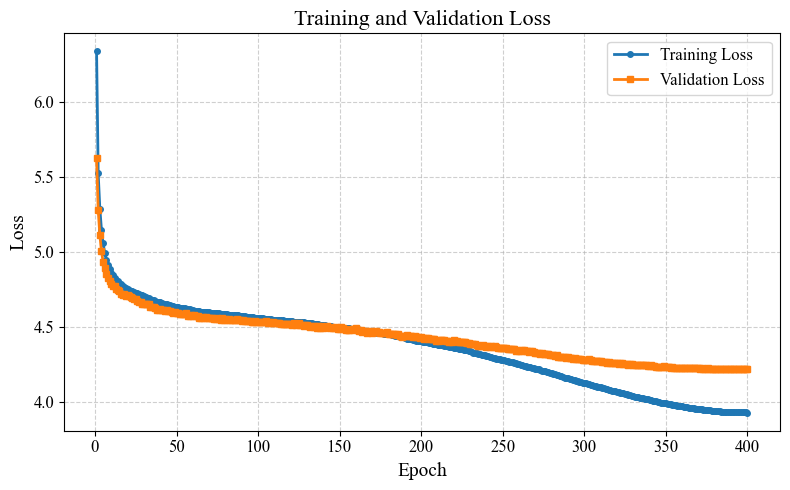

In [69]:
plot_losses("./BPE/BPE.csv")

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_losses_unigram(csv_file, save_path=None, dpi=300):
    """
    Read a CSV containing Train and Validation losses and plot them.

    Expected CSV format:
    Epoch,Train Loss,Val Loss
    1,2.34,2.56
    2,1.98,2.21
    ...

    Parameters
    ----------
    csv_file : str
        Path to CSV file.
    save_path : str, optional
        If provided, saves the figure to this path.
    dpi : int, optional
        Figure resolution when saving.
    """

    # Use Times New Roman
    plt.rcParams["font.family"] = "Times New Roman"

    df = pd.read_csv(csv_file)

    # Find columns (case-insensitive)
    cols = {c.lower(): c for c in df.columns}

    train_col = next(
        (cols[c] for c in cols if "train" in c and "loss" in c),
        None
    )
    val_col = next(
        (cols[c] for c in cols if ("val" in c or "valid" in c) and "loss" in c),
        None
    )

    if train_col is None or val_col is None:
        raise ValueError(
            "CSV must contain columns similar to 'Train Loss' and 'Val Loss'."
        )

    if "epoch" in cols:
        x = df[cols["epoch"]]
        xlabel = "Epoch"
    else:
        x = range(1, len(df) + 1)
        xlabel = "Epoch"

    plt.figure(figsize=(8, 5))

    plt.plot(
        x,
        df[train_col]/3103,
        linewidth=2,
        marker="o",
        markersize=4,
        label="Training Loss"
    )

    plt.plot(
        x,
        df[val_col]/397,
        linewidth=2,
        marker="s",
        markersize=4,
        label="Validation Loss"
    )

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel("Loss", fontsize=14)
    plt.title("Training and Validation Loss", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

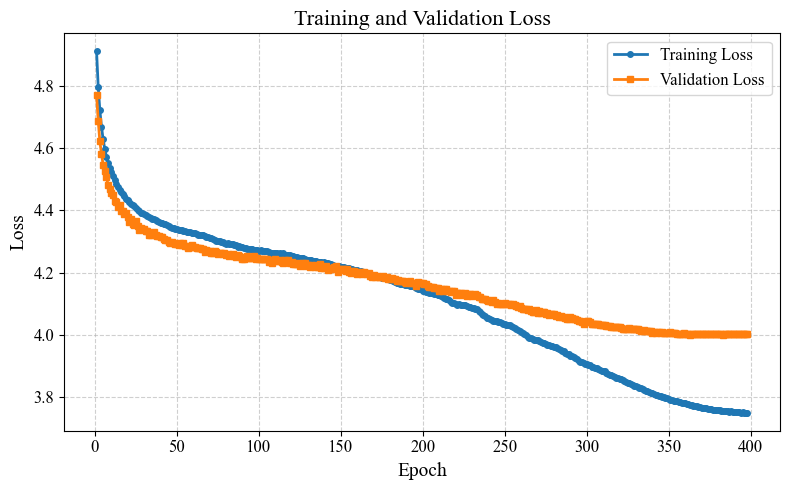

In [83]:
plot_losses_unigram("./Unigram/Unigram.csv")

In [76]:
print(len(dataloader_test))
print(len(dataloader_train))


397
3103


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

def plot_multiple_histories(
    csv_files,
    model_names,
    colors=None,
    save_path=None,
    dpi=600
):
    """
    Plot train/validation loss curves from multiple training runs.

    Parameters
    ----------
    csv_files : list[str]
        Paths to CSV files.

    model_names : list[str]
        Names to show in legend.

    colors : list[str], optional
        Matplotlib-compatible colors.

    save_path : str, optional
        Save figure to file.

    Expected CSV columns:
        Epoch, Train Loss, Val Loss
    """

    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 11,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })

    # Colorblind-friendly palette
    if colors is None:
        colors = [
            "#0072B2",  # blue
            "#D55E00",  # vermillion
            "#009E73",  # green
            "#CC79A7",  # purple
            "#E69F00",  # orange
        ]

    fig, ax = plt.subplots(figsize=(9, 6))

    for csv_file, model_name, color in zip(
        csv_files,
        model_names,
        colors
    ):
        df = pd.read_csv(csv_file)

        cols = {c.lower(): c for c in df.columns}

        train_col = next(
            (cols[c] for c in cols if "train" in c and "loss" in c),
            None
        )

        val_col = next(
            (cols[c] for c in cols
             if ("val" in c or "valid" in c) and "loss" in c),
            None
        )

        if train_col is None or val_col is None:
            raise ValueError(
                f"Could not identify loss columns in {csv_file}"
            )

        if "epoch" in cols:
            epochs = df[cols["epoch"]]
        else:
            epochs = range(1, len(df) + 1)

        # Training curve
        ax.plot(
            epochs,
            df[train_col],
            color=color,
            linewidth=2.5,
            label=f"{model_name} (Train)"
        )

        # Validation curve
        ax.plot(
            epochs,
            df[val_col],
            color=to_rgba(color, alpha=0.45),
            linewidth=2.5,
            linestyle="--",
            label=f"{model_name} (Validation)"
        )

    # Publication-quality styling
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training and Validation Loss Comparison")

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.5,
        alpha=0.4
    )

    # Remove clutter
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Compact legend
    ax.legend(
        frameon=False,
        ncol=2,
        loc="upper right"
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()

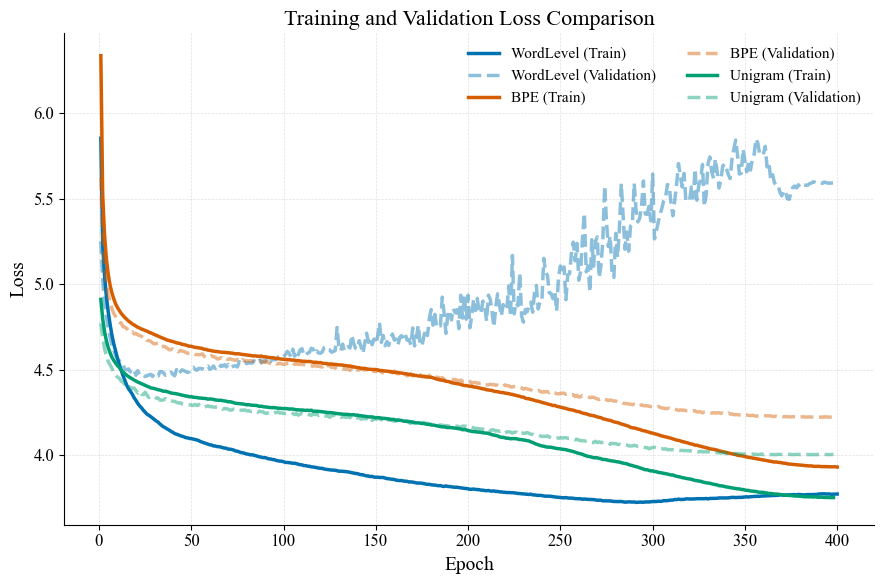

In [88]:
plot_multiple_histories(
    csv_files=[
        "./wordlevel/wordlevel.csv",
        "./BPE/BPE.csv",
        "./Unigram/Unigram_2.csv"
    ],
    model_names=[
        "WordLevel",
        "BPE",
        "Unigram"
    ],
    save_path="loss_comparison.pdf"
)